# 실제 EEG 분류 디코더로 SO-101 팔 + AmazingHand 손 동시 구동 (공식 시뮬레이션)

`neural-to-output` 프로젝트와 독립적인 sandbox입니다 (`pyproject.toml`/`uv.lock` 미수정, `01`~`03`번
노트북과 같은 `examples` 의존성 그룹만 사용합니다).

**목표**: 실제 AmazingHand가 물리적으로 연결되어 있지만, 벤더의 실제 하드웨어 제어 예제
(`pollen-robotics/AmazingHand`의 `PythonExample/AmazingHand_Demo.py`, `rustypot` + Feetech 서보 기반)에는
**가동 범위 제한(joint limit)이 전혀 없습니다**. `huggingface/lerobot`의 `SO101Follower`도 실제 시리얼
포트로 연결된 하드웨어만 지원하고 공식 시뮬레이션 모드가 없습니다. 그래서 실제 로봇을 움직이기 전에,
각 로봇의 **공식 CAD/URDF/MJCF 출처**(추측한 값이 아니라 벤더가 실제로 공개한 관절 이름·가동범위)를 그대로
가져와, `02`번 노트북과 같은 **실제 EEG 데이터 + 분류(classification) 디코더**로 팔(SO-101)과
손(AmazingHand)을 동시에 구동합니다.

이번 버전은 `n2o`의 두 단계 역할을 분명하게 분리합니다 (이전 버전에서는 decoder 하나가 이 역할을
전부 떠맡고 있었습니다):

1. **`Decoder`** — 순수 분류기. EEG 윈도우를 보고 데이터셋의 원시 라벨(`"left_hand"`/`"right_hand"`)
   그대로를 반환할 뿐, 로봇 쪽 사정은 전혀 모릅니다.
2. **`Command`** — 그 라벨을 각 로봇 부품이 수행할 행동 이름으로 매핑합니다
   (`"left_hand"` -> `{"arm": "up", "hand": "grip"}`).

그 행동 이름을 실제로 움직임으로 바꾸는 건 `n2o.robot.Part`(`SO101Arm`/`AmazingHand`)의 몫입니다 —
`goal(cmd)`는 입출력 없는 순수 계산으로 목표값을 반환하고, `move(cmd)`는 실제 하드웨어를 구동합니다.
예전처럼 `RobotArm`/`RobotHand` ABC와 별도의 `n2o.robot.controller.Controller` 클래스가 그 사이에 끼어드는
3단 구조가 아니라, `Part` 하나로 통합됐습니다. `n2o.robot.simulation.Simulator`(`robot.simulator`에 할당)가
`Part.goal()`이 반환한 목표값을 받아 MuJoCo에 그대로 반영합니다 — `Robot.router()`가
`ControllerType.SIMULATION`일 때 자동으로 `goal()` -> `Simulator.drive()` 순서로 호출해줍니다.

- **SO-101 팔**: `lerobot`이 아니라 실제 하드웨어/CAD 저장소인
  [`TheRobotStudio/SO-ARM100`](https://github.com/TheRobotStudio/SO-ARM100)(Apache-2.0)의
  `Simulation/SO101/`을 그대로 사용합니다 (`robot/arm/so101/NOTICE.md` 참고, 이제
  `n2o.robot.simulation`이 내부적으로 소유합니다). 관절 이름(`shoulder_pan`,
  `shoulder_lift`, `elbow_flex`, `wrist_flex`, `wrist_roll`, `gripper`)은 `lerobot`의 `SO101Follower`가
  실제로 쓰는 이름과 정확히 일치합니다.
- **AmazingHand**: `examples/robot/hand/amazing_hand_right/`가
  [`pollen-robotics/AmazingHand`](https://github.com/pollen-robotics/AmazingHand)의 공식
  `Demo/AHSimulation` 출력과 실제로 일치하는지 다시 대조 검증했습니다 (`NOTICE.md` 참고) — 관절
  가동범위(`finger{1-4}_motor{1,2}`, 각 ±90°)가 공식 CAD 그대로이므로, MuJoCo의 위치 액추에이터가
  이 범위를 넘어서는 명령을 자동으로 clamp합니다.

이 노트북은 **시뮬레이션만** 다룹니다 — `SO101Arm`/`AmazingHand`(둘 다 `n2o.robot.Part`의 실제 구현체)를
실제로 인스턴스화하긴 하지만, `n2o.run(controller="simulation")` 경로에서는 `goal()`(입출력 없는 순수
계산)만 호출되고 `move()`(실제 하드웨어 구동)는 전혀 호출되지 않습니다 — 물리적으로 연결된 실제
AmazingHand에는 어떤 명령도 보내지 않습니다.

In [ ]:
import os
import warnings

os.environ.setdefault(
    "MUJOCO_GL", "egl"
)  # 디스플레이 없는 환경에서도 오프스크린 렌더링

import matplotlib.pyplot as plt
import mne
import mujoco
import numpy as np
import torch
from braindecode.models import EEGNet
from braindecode.preprocessing import create_windows_from_events

from n2o import N2O
from n2o.command import Command, CommandConfig
from n2o.decoder import (
    Classification,
    DecoderConfig,
    DecoderType,
    FeatureType,
    bandpass_standardize,
)
from n2o.robot.arm.so101 import SO101Arm
from n2o.robot.hand.amazing_hand_right import AmazingHand
from n2o.robot.simulation import Simulator
from n2o.signal.dataset import DatasetLoader

warnings.filterwarnings("ignore")  # mne/braindecode의 사소한 UserWarning 숨김
mne.set_log_level("ERROR")  # mne의 시끄러운 필터 설계 로그(INFO) 숨김

ARM_JOINTS = [
    "shoulder_pan",
    "shoulder_lift",
    "elbow_flex",
    "wrist_flex",
    "wrist_roll",
    "gripper",
]

## 1. EEG 데이터 로드 및 전처리

`02_hand_intent_classification_amazinghand.ipynb`와 동일한 subject 1 데이터를,
`braindecode.datasets.MOABBDataset`를 직접 부르는 대신 `n2o.signal.dataset.DatasetLoader`로 불러오고,
같은 밴드패스(4-38Hz) + 표준화 전처리를 `n2o.decoder.bandpass_standardize()`로 적용합니다 (자세한
설명/시각화는 `01_explore_eeg_decoder.ipynb`, `02_hand_intent_classification_amazinghand.ipynb` 참고).

In [ ]:
dataset = DatasetLoader(
    name="BNCI2014_001"
).read()  # subject 1의 raw 레코딩만 (n2o.signal의 역할은 로딩까지)
bandpass_standardize(
    dataset
)  # 4-38Hz 밴드패스 + exponential-moving-standardize, in place -- n2o.decoder의 역할

raw = dataset.datasets[0].raw
print("preprocessed n_channels:", len(raw.ch_names))
print("preprocessed data shape:", raw.get_data().shape)

## 2. 윈도잉 + 2클래스로 필터링

`left_hand`/`right_hand` 두 클래스만 남기고 나머지(`feet`, `tongue`)는 제외합니다. 이전 노트북들과
달리 `"grip"`/`"spread"` 같은 도메인 용어로 **재해석하지 않습니다** — `Decoder`는 데이터셋의 원시
라벨을 그대로 내보내는 순수 분류기여야 하고, 그 라벨을 로봇 행동으로 바꾸는 건 다음 절의 `Command`가
할 일이기 때문입니다.

In [3]:
LABELS = ["left_hand", "right_hand"]
_ORIGINAL_TO_INDEX = {1: 0, 2: 1}  # left_hand(1)->0, right_hand(2)->1

sfreq = dataset.datasets[0].raw.info["sfreq"]
trial_start_offset_samples = int(-0.5 * sfreq)

windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=trial_start_offset_samples,
    trial_stop_offset_samples=0,
    preload=True,
)


class LabelSubset(torch.utils.data.Dataset):
    """원본 4클래스 windows_dataset에서 left_hand/right_hand 트라이얼만 남기고 라벨을 0/1로 재매핑합니다."""

    def __init__(self, base):
        self.base = base
        self.index_map = [
            (i, _ORIGINAL_TO_INDEX[base[i][1]])
            for i in range(len(base))
            if base[i][1] in _ORIGINAL_TO_INDEX
        ]

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        base_idx, label_idx = self.index_map[idx]
        X, _, crop_inds = self.base[base_idx]
        return X, label_idx, crop_inds


splitted = windows_dataset.split("session")
train_key, valid_key = list(splitted.keys())[:2]
train_set = LabelSubset(splitted[train_key])
valid_set = LabelSubset(splitted[valid_key])

X0, y0, _ = train_set[0]
n_chans, input_window_samples = X0.shape
print(f"train trials: {len(train_set)}, valid trials: {len(valid_set)}")
print(f"n_chans={n_chans}, n_times={input_window_samples}")

train trials: 144, valid trials: 144
n_chans=22, n_times=1125


## 3. `SO101Arm`/`AmazingHand` + `Simulator`: 공식 CAD 시뮬레이션

`SO101Arm`(`n2o.robot.arm.so101`)과 `AmazingHand`(`n2o.robot.hand.amazing_hand_right`)는 둘 다 실제
`n2o.robot.Part` 구현체입니다 — `goal(cmd)`는 `GESTURES`(`"up"`/`"down"`, `"grip"`/`"release"`, ...) 딕셔너리
조회일 뿐인 순수 계산이고, `move(cmd)`는 (이 노트북에서는 호출되지 않는) 실제 하드웨어 구동입니다.

`n2o.robot.simulation.Simulator(parts, *, attach_hand_to_arm=False)`가 그 `goal()` 결과를 받아
`robot/arm/so101/mjcf/scene.xml`(`TheRobotStudio/SO-ARM100`에서 그대로 가져온 파일)과
`robot/hand/amazing_hand_right/mjcf/robot.xml`(`pollen-robotics/AmazingHand`와 대조 검증된 파일)을 **하나의
MJCF 스펙, 하나의 창**으로 합칩니다 — `parts`에 `"arm"`/`"hand"` 둘 다 넘기면 팔과 손이 서로 다른
MuJoCo 창이 아니라 같은 물리 세계/같은 창에 뜹니다. `attach_hand_to_arm=True`면 손이 팔의
`gripperframe` 사이트에 실제로 용접되어(하나의 운동학적 트리) 팔을 따라 함께 움직이고, 기본값
`False`면 같은 창/물리 세계에 있되 서로 붙어있지는 않습니다(옆에 나란히 배치).

`drive(part, target)`은 물리 스텝만 진행하는 headless-safe 호출이고, `render()`는 그 결과를(합쳐진
장면 전체를) RGB 프레임 하나로 돌려줍니다(오프스크린 EGL 렌더링, 이 노트북 맨 위에서 이미 설정).
`launch_viewer()`는 실제 디스플레이가 있는 환경에서 라이브 MuJoCo 창을 여는 별도 방법으로,
`n2o.run(controller="simulation")`이 (아래 7절에서) 자동으로 호출해줍니다 — 여기서는 이 노트북의
헤드리스 환경에 맞춰 `render()` + `imshow()`로 대신 시연합니다.

MuJoCo의 위치 액추에이터가 공식 가동범위를 벗어나는 값을 자동으로 clamp해줍니다.

In [ ]:
sim = Simulator(["arm", "hand"])  # both parts share one window/physics world

arm_part = SO101Arm()
target = arm_part.goal("up")  # 순수 계산(입출력 없음) -- 5개 관절 목표(degree)
print("SO101Arm.goal('up') ->", target)

sim.drive("arm", target)  # MuJoCo에 반영 (headless-safe) -- 손은 아직 기본 자세
plt.figure(figsize=(5, 4))
plt.imshow(sim.render())
plt.axis("off")
plt.title("SO-101 arm -> 'up' (hand still at rest, same scene)")
plt.show()

In [ ]:
hand_part = AmazingHand()
target = hand_part.goal("grip")  # 순수 계산(입출력 없음) -- 8개 모터 목표(라디안)
print("AmazingHand.goal('grip') ->", target)

sim.drive("hand", target)  # 같은 sim, 같은 창 -- 팔은 방금 그 'up' 자세 그대로
plt.figure(figsize=(5, 4))
plt.imshow(sim.render())
plt.axis("off")
plt.title("SO-101 arm ('up') + AmazingHand ('grip') -- one window")
plt.show()

## 4. `Decoder` 서브클래스: 순수 EEGNet 분류기

`n2o.decoder.Classification`을 상속하지만, `decode(signal)`은 EEGNet의 예측 결과를 데이터셋 원래 라벨
문자열(`"left_hand"`/`"right_hand"`) 그대로 반환할 뿐입니다 — 로봇이 몇 개인지, 어떻게 움직여야
하는지는 전혀 모릅니다. `Decoder`를 직접 상속하지 않는 이유는 `Classification`이 이산 클래스 라벨
디코더용 `preprocess()`/`window()`를 이미 구현해두고 있어서입니다. `output_type = FeatureType.ACTION`으로
선언하고 `config.type`을 `DecoderType.CLASSIFICATION`으로 표시합니다. `output_spec`을 명시해두면
`CommandConfig.verify_report()`가 다음 단계(`command`)의 계약과 이 값을 대조해줍니다.

In [ ]:
class MotorImageryDecoder(Classification):
    """EEGNet 기반 left_hand/right_hand 운동 심상(motor imagery) 분류기 — 순수 분류만 합니다."""

    output_type = FeatureType.ACTION

    def __init__(self, n_chans, n_times):
        self.input_spec = {"n_chans": n_chans, "n_times": n_times}
        self.output_spec = {"label": "left_hand | right_hand"}
        self.config = DecoderConfig(type=DecoderType.CLASSIFICATION)
        self.model = EEGNet(n_chans=n_chans, n_outputs=len(LABELS), n_times=n_times)

    @property
    def device(self):
        # print(model)이 내부적으로 torchinfo summary를 실행하면서 모델을 GPU로 옮길 수 있어,
        # 캐싱하지 않고 매번 모델의 실제 현재 위치를 조회합니다.
        return next(self.model.parameters()).device

    def decode(self, signal):
        self.model.eval()
        with torch.no_grad():
            x = torch.tensor(signal).unsqueeze(0).float().to(self.device)
            logits = self.model(x)
        return LABELS[int(logits.argmax(dim=1).item())]


decoder = MotorImageryDecoder(n_chans=n_chans, n_times=input_window_samples)
print(decoder.model)

## 5. `Command`: 라벨을 팔+손 행동으로 매핑

`decoder`가 반환하는 원시 라벨 하나(`decoded_signal`)로 팔과 손이 각각 무슨 행동을 할지 결정하는 게
`Command.translate()`의 역할입니다. `n2o.command`에 설정해두면 `N2O.run()`이 자동으로
`command.translate(decoder, decoded_signal)`을 호출해서
`robot.arm.move(actions["type"], actions["arm"])`, `robot.hand.move(actions["type"], actions["hand"])`로
나눠 보냅니다.

In [7]:
class MotorImageryCommand(Command):
    """단일 라벨(`decoded_signal`)로 팔+손이 각각 취할 행동 이름을 결정합니다."""

    def translate(self, decoder, decoded_signal):
        command = {"type": decoder.config.type, "arm": None, "hand": None}
        if decoded_signal == "left_hand":
            command["arm"], command["hand"] = "up", "grip"
        elif decoded_signal == "right_hand":
            command["arm"], command["hand"] = "down", "release"
        return command


command = MotorImageryCommand()

## 6. 학습 sanity check

`02`번 노트북과 동일하게, 작은 고정 배치 하나를 반복 학습시켜서 loss가 떨어지고 accuracy가 오르는지만
확인하는 오버피팅 sanity check입니다 (제대로 된 학습이 아니므로, 아래 검증 샘플에서 실제 라벨과 다르게
분류되는 경우가 있어도 정상입니다 — 이 노트북의 목표는 분류 정확도가 아니라 파이프라인 연결입니다).

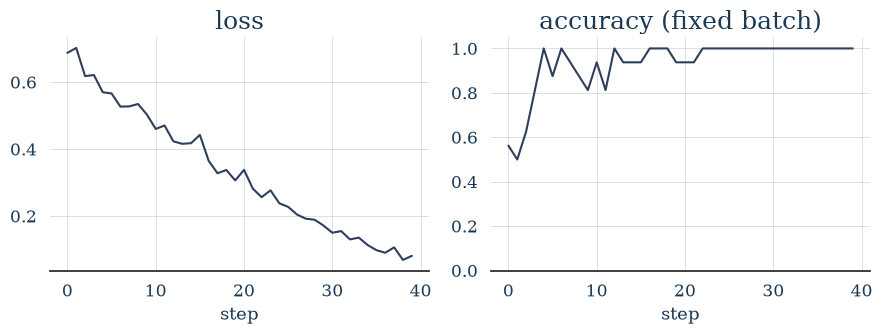

마지막 step: loss=0.0811, acc=1.00


In [8]:
decoder.model.train()
opt = torch.optim.Adam(decoder.model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

n_batch = min(16, len(train_set))
xs = np.stack([train_set[i][0] for i in range(n_batch)])
ys = np.array([train_set[i][1] for i in range(n_batch)])
X_batch = torch.from_numpy(xs).float().to(decoder.device)
y_batch = torch.from_numpy(ys).long().to(decoder.device)

n_steps = 40
history = {"loss": [], "acc": []}
for step in range(n_steps):
    opt.zero_grad()
    logits = decoder.model(X_batch)
    loss = loss_fn(logits, y_batch)
    loss.backward()
    opt.step()
    acc = (logits.argmax(dim=1) == y_batch).float().mean().item()
    history["loss"].append(loss.item())
    history["acc"].append(acc)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(history["loss"])
axes[0].set_title("loss")
axes[0].set_xlabel("step")
axes[1].plot(history["acc"])
axes[1].set_title("accuracy (fixed batch)")
axes[1].set_xlabel("step")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"마지막 step: loss={history['loss'][-1]:.4f}, acc={history['acc'][-1]:.2f}")

## 7. `N2O` 파이프라인으로 실제 검증 샘플 구동

학습에 쓰지 않은 검증(validation) 세트에서 샘플 몇 개를 뽑아 `signal.read()`가 순서대로 돌려주도록
하고, `N2O`가 실제로 EEG -> decoder(라벨) -> command(팔+손 행동) -> robot.arm/hand까지 전체
파이프라인을 통과시키는지 확인합니다.

In [ ]:
class ValidationSampleSignal:
    """검증 세트의 EEG 윈도우를 순서대로 돌려주는 signal 소스."""

    def __init__(self, samples):
        self.samples = samples
        self.i = 0

    def read(self):
        sample = self.samples[self.i]
        self.i += 1
        return sample


N_SAMPLES = 4
samples = [valid_set[i][0] for i in range(N_SAMPLES)]
true_labels = [LABELS[valid_set[i][1]] for i in range(N_SAMPLES)]

n2o = N2O()
n2o.signal = ValidationSampleSignal(samples)
n2o.decoder = decoder
n2o.command = command
n2o.robot.arm = SO101Arm()
n2o.robot.hand = AmazingHand()

n2o.command_config = CommandConfig()
print(n2o.command_config.verify_report(n2o))

In [ ]:
for i in range(N_SAMPLES):
    predicted_label = decoder(samples[i])
    predicted_command = command.translate(decoder, predicted_label)
    print(
        f"--- 검증 샘플 {i + 1}/{N_SAMPLES} "
        f"(실제 라벨: {true_labels[i]}, 예측 라벨: {predicted_label}, "
        f"명령: {predicted_command}) ---"
    )
    n2o.run(controller="simulation")

## 8. 가동범위 확인

마지막으로, 팔의 각 관절이 실제로 `robot/arm/so101/mjcf`에 박혀 있는 공식 가동범위 안에 있었는지
직접 확인합니다 — 이 값들은 저희가 추측한 게 아니라 `TheRobotStudio/SO-ARM100`이 공개한 실제 값입니다.

In [ ]:
print("관절별 가동범위 확인 (공식 벤더 값 기준):")
# n2o.robot.arm(SO101Arm)은 goal()만 순수 계산하고 MuJoCo 상태는 갖지 않으므로, 실제 물리
# 상태는 n2o.run(controller="simulation")이 자동으로 만든 Simulator가 내부에 들고 있습니다.
# Simulator.model/.data가 공개 API로 노출하는 공유 모델/데이터를 직접 읽습니다 (arm은
# 항상 prefix 없이 합쳐지므로 actuator_name("arm", joint)는 joint 그대로를 돌려줍니다).
simulator = n2o.robot.simulator
for joint in ARM_JOINTS:
    name = simulator.actuator_name("arm", joint)
    joint_id = mujoco.mj_name2id(simulator.model, mujoco.mjtObj.mjOBJ_JOINT, name)
    lo, hi = simulator.model.jnt_range[joint_id]
    value = simulator.data.qpos[joint_id]
    status = "OK" if lo - 1e-6 <= value <= hi + 1e-6 else "범위 초과"
    print(
        f"  {joint:14s}: {value:6.3f} rad   (공식 범위 [{lo:6.3f}, {hi:6.3f}])   {status}"
    )

## 정리

- `Classification`(`MotorImageryDecoder`)은 순수 분류기로만 남았습니다 — EEGNet의 예측을 데이터셋 원시
  라벨(`"left_hand"`/`"right_hand"`) 그대로 반환할 뿐, 로봇 쪽 사정을 전혀 모릅니다.
  `output_type = FeatureType.ACTION`, `config.type = DecoderType.CLASSIFICATION`으로 표시했습니다.
- `MotorImageryCommand.translate()`가 그 라벨을 팔+손 각각의 행동 이름으로 매핑합니다
  (`"left_hand"` -> `{"arm": "up", "hand": "grip"}`). `n2o.command`를 설정해두면 `N2O.run()`이
  자동으로 이 매핑을 거쳐 `Robot.router()`에 넘깁니다.
- `SO101Arm`/`AmazingHand`(둘 다 `n2o.robot.Part`의 실제 구현체)가 행동 이름 하나를 실제 목표값으로
  바꿉니다 — `goal(cmd)`는 입출력 없는 순수 계산으로 목표값을 반환하고, `move(cmd)`는 실제 하드웨어를
  구동합니다. 예전의 `RobotArm`/`RobotHand` ABC + `n2o.robot.controller.Controller`(예전
  `MotorWrapper`) 3단 구조는 `Part` 하나로 통합됐습니다 — 별도의 `Controller` 클래스는 더 이상 존재하지
  않습니다.
- `n2o.robot.simulation.Simulator`가 `goal()`이 반환한 목표값을 받아 MuJoCo에 반영합니다 —
  `n2o.run(controller="simulation")` 한 줄이면 할당된 모든 부품(`robot.arm`/`robot.hand`)을 하나의
  MJCF 스펙으로 합친 `Simulator`를 자동으로 만들고(`robot.simulator`), 그 부품 전체를 위한 라이브 뷰어
  창을 **하나만** 열어줍니다(`launch_viewer()`) -- 팔과 손이 서로 다른 창에 뜨지 않습니다.
  `robot.attach_hand_to_arm = True`면 손이 팔의 `gripperframe` 사이트에 용접되어 팔을 따라 함께
  움직이고, 기본값(`False`)이면 같은 창/물리 세계에 있되 서로 붙어있지는 않습니다. 이 노트북은 헤드리스
  EGL 환경에 맞춰, 3절 데모 셀에서는 대신 `Simulator.render()`로 (합쳐진 장면 전체의) 프레임을 직접
  캡처해 인라인으로 표시했습니다.
- `CommandConfig.verify_report()`로 signal -> decoder -> command -> robot.arm/robot.hand 네 경계를
  모두 확인했고, 검증 세트의 실제 EEG 샘플들을 `n2o.run(controller="simulation")`으로 흘려보내
  파이프라인이 예외 없이 끝까지 동작하는 것을 확인했습니다 (학습은 오버피팅 sanity check 수준이라
  예측이 실제 라벨과 다를 수 있음 — 파이프라인 연결 자체를 확인하는 것이 목표입니다).
- SO-101 팔은 `lerobot`이 아니라 실제 하드웨어/CAD 저장소인 `TheRobotStudio/SO-ARM100`에서 그대로
  가져온 MJCF로, AmazingHand는 `pollen-robotics/AmazingHand`의 공식 `Demo/AHSimulation` 출력과
  대조 검증한 자산으로 시뮬레이션했습니다 (이제 두 자산 모두 `n2o.robot.simulation`이 내부적으로
  소유합니다 — 노트북이 직접 MJCF 경로를 로드하지 않습니다).
- 두 로봇 모두 명령이 각 벤더의 공식 가동범위를 벗어나지 않았음을 직접 확인했습니다 — MuJoCo의 위치
  액추에이터가 MJCF에 박힌 공식 `range`를 자동으로 clamp해주기 때문에, 저희가 별도로 안전장치를
  구현하지 않아도 이 시뮬레이션 안에서는 안전합니다 (반면 `AmazingHand`의 실제 하드웨어 예제 코드에는
  이런 clamp가 없습니다 — 실제 연결 시에는 별도 안전장치가 필요합니다).
- `SO101Arm`/`AmazingHand`는 이 노트북에서 실제로 인스턴스화됐지만, `goal()`만 호출됐습니다 — `move()`
  (실제 하드웨어 구동)는 한 번도 호출되지 않았으므로, 물리적으로 연결된 실제 AmazingHand는 전혀
  건드리지 않았습니다.
- 이 시뮬레이션을 실제 하드웨어 구동으로 바꾸려면 `n2o.run(controller="motor_driver")`로 바꾸기만 하면
  됩니다 — `SO101Arm.move()`/`AmazingHand.move()`가 이미 각각 실제 드라이버(lerobot 시리얼 연결 /
  `rustypot` 서보 SDK)를 직접 감싸고 있으므로, `Decoder`/`Command` 연결 코드는 그대로 재사용됩니다.